### Jupyter Notebooks y Google Colab

Jupyter Notebooks y Google Colab son herramientas similares (la segunda está basada en la primera). La diferencia más importante es que Jupyter NB permite trabajar off-line al instalarse de forma local (ej: con Anaconda) mientras que Colab permite trabajar on-line al alojarse en los servidores de Google Cloud. A manera de introducción pude ver los siguientes videos donde se muestra el funcionamiento básico de los entornos:

https://www.youtube.com/watch?v=8VFYs3Ot_aA

https://www.youtube.com/watch?v=KajSbrEBZ5kZ5k


# Librerías

In [48]:
import pandas as pd
import matplotlib.pyplot as plt


# Accediendo a los datos

### Descripción del dataset Autos MPG

El conjunto de datos **Autos MPG** proviene del repositorio de UCI Machine Learning y se utiliza principalmente para analizar el consumo de combustible de distintos modelos de automóviles. La variable objetivo es el rendimiento en millas por galón (mpg), y se relaciona con diversas características técnicas de los vehículos.  

**Atributos:**
- **mpg**: rendimiento de combustible en millas por galón (variable continua).  
- **cylinders**: número de cilindros del motor (variable discreta multivaluada).  
- **displacement**: desplazamiento del motor en pulgadas cúbicas (variable continua).  
- **horsepower**: potencia del motor (variable continua).  
- **weight**: peso del automóvil (variable continua).  
- **acceleration**: aceleración en segundos para alcanzar cierta velocidad (variable continua).  
- **model year**: año de fabricación, entre 1970 y 1982 (variable discreta multivaluada).  
- **origin**: lugar de fabricación (1 = USA, 2 = Europa, 3 = Asia).  
- **car name**: nombre del modelo de automóvil (texto único por instancia).  


In [49]:
path = 'https://weblidi.info.unlp.edu.ar/catedras/MD_SI/DATOS/'

df = pd.read_csv(path + 'autos-mpg.csv', sep=';')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,ocho,3070,130.0,3504,120,70,1,chevrolet chevelle malibu
1,15.0,ocho,3500,165.0,3693,115,70,1,buick skylark 320
2,18.0,ocho,3180,150.0,3436,110,70,1,plymouth satellite
3,16.0,ocho,3040,150.0,3433,120,70,1,amc rebel sst
4,17.0,ocho,3020,140.0,3449,105,70,1,ford torino


# Información del dataframe

El método **info()** imprime información sobre el DataFrame. La información contiene el número de columnas, las etiquetas de las columnas, los tipos de datos de las columnas, el uso de la memoria, el índice de rango y el número de celdas en cada columna (valores no nulos).

In [50]:
# info() muestra información del DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     406 non-null    object 
 2   displacement  406 non-null    int64  
 3   horsepower    400 non-null    float64
 4   weight        406 non-null    int64  
 5   acceleration  406 non-null    int64  
 6   model_year    406 non-null    int64  
 7   origin        406 non-null    int64  
 8   car_name      406 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 28.7+ KB
None


El atributo *origin* indica el país de fabricación del vehiculo: 1-USA, 2-Europa, 3-Japón. El método **value_counts()** indica la cantidad de autos que hay de cada tipo. Como puede verse la mayoría fue fabricado en USA.

In [51]:
df["origin"].value_counts()

,count
origin,
1,254
3,79
2,73


## Filtrando registros
Selección de autos de origen USA con una potencia de motor inferior a 100 hp

In [52]:
# Filtrar las filas donde 'origin' es 1 y 'horsepower' es menor que 100
df_filtered = df[(df['origin'] == 1) & (df['horsepower'] < 100)]

# Mostrar las primeras filas del DataFrame filtrado
df_filtered.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
21,22.0,seis,1980,95.0,2833,155,70,1,plymouth duster
22,18.0,seis,1990,97.0,2774,155,70,1,amc hornet
23,21.0,seis,2000,85.0,2587,160,70,1,ford maverick
30,21.0,seis,1990,90.0,2648,150,70,1,amc gremlin
36,28.0,cuatro,1400,90.0,2264,155,71,1,chevrolet vega 2300


El método **drop()** elimina columnas

In [53]:
# Generar un nuevo DataFrame eliminando las columnas 'mpg' y 'car_name'
df_sin_columnas = df.drop(columns=['mpg', 'car_name'])

# Mostrar las primeras filas del nuevo DataFrame
display(df_sin_columnas.head())

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,ocho,3070,130.0,3504,120,70,1
1,ocho,3500,165.0,3693,115,70,1
2,ocho,3180,150.0,3436,110,70,1
3,ocho,3040,150.0,3433,120,70,1
4,ocho,3020,140.0,3449,105,70,1


#Gráficos

## Histograma

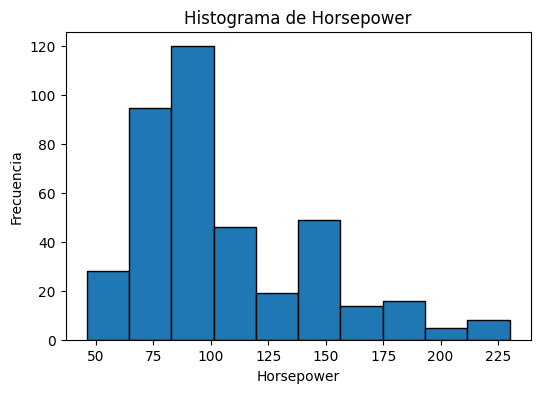

In [54]:
# @title
# Histograma del atributo horsepower usando matplotlib
plt.figure(figsize=(6, 4)) # Define el tamaño de la figura (ancho, alto)
plt.hist(df['horsepower'], bins = 10, edgecolor = 'black', linewidth=1)
plt.xlabel('Horsepower')
plt.ylabel('Frecuencia')
plt.title('Histograma de Horsepower')
plt.show()

Text(0.5, 1.0, 'Histograma de acceleration')

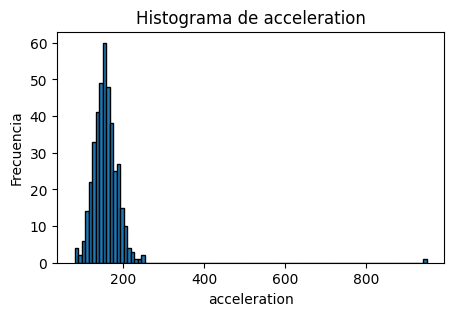

In [55]:
# @title
#-- histograma del atributo indicado en COL --
col = "acceleration"
plt.figure(figsize = (5,3))
plt.hist(df[col], bins = 100, edgecolor = 'black', \
         linewidth=1)
plt.xlabel(col)
plt.ylabel('Frecuencia')
plt.title('Histograma de ' + col)

## Diagrama de barras

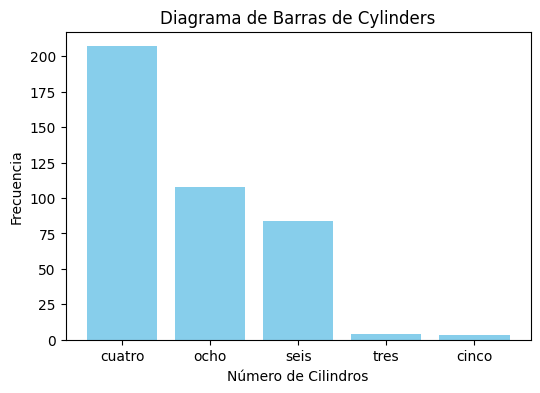

In [56]:
# @title
# Obtener el recuento de cada valor único en la columna 'cylinders'
cylinder_counts = df['cylinders'].value_counts()

# Crear el diagrama de barras
plt.figure(figsize=(6, 4)) # Define el tamaño de la figura
plt.bar(cylinder_counts.index, cylinder_counts.values, color='skyblue')

# Añadir etiquetas y título
plt.xlabel('Número de Cilindros')
plt.ylabel('Frecuencia')
plt.title('Diagrama de Barras de Cylinders')

# Mostrar el gráfico
plt.show()

## Gráfico de torta

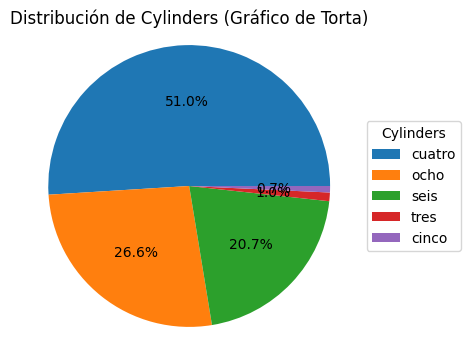

In [57]:
# @title
# Obtener el recuento de cada valor único en la columna 'cylinders'
cylinder_counts = df['cylinders'].value_counts()

# Crear el gráfico de torta
plt.figure(figsize=(4,4)) # Define el tamaño de la figura para un gráfico de torta
#plt.pie(cylinder_counts, labels=cylinder_counts.index, autopct='%1.1f%%')
plt.pie(cylinder_counts, autopct='%1.1f%%')

# Añadir un título
plt.title('Distribución de Cylinders (Gráfico de Torta)')

# Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

# Agregar la leyenda fuera del gráfico
plt.legend(title="Cylinders", labels=cylinder_counts.index, bbox_to_anchor=(1.05, 0.5), loc="center left")

# Mostrar el gráfico
plt.show()

## Diagrama de dispersión

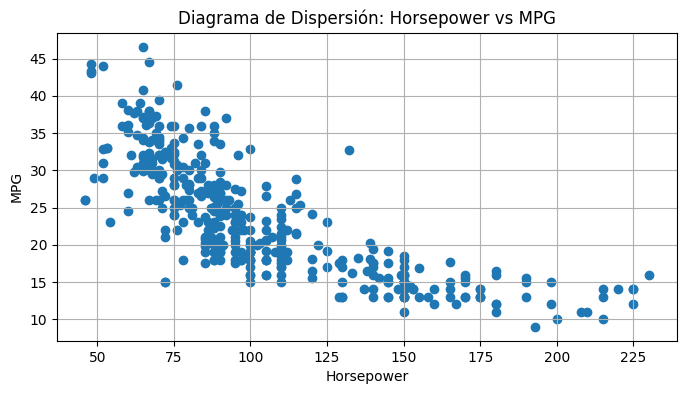

In [73]:
# @title
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.scatter(df['horsepower'], df['mpg'])
plt.title('Diagrama de Dispersión: Horsepower vs MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.grid(True)
plt.show()

## Gráficos usando seaborn

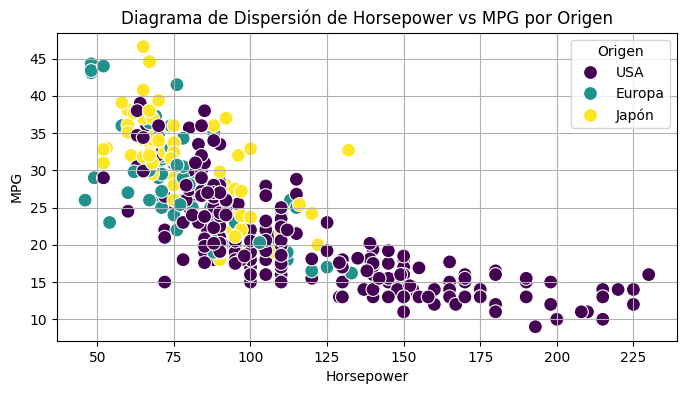

In [59]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='horsepower', y='mpg', hue='origin', palette='viridis', s=100)

# Add titles and labels for clarity
plt.title('Diagrama de Dispersión de Horsepower vs MPG por Origen')
plt.xlabel('Horsepower')
plt.ylabel('MPG')

# Improve legend to show origin names instead of numbers
hue_labels = {1: 'USA', 2: 'Europa', 3: 'Japón'}
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [hue_labels.get(int(label), label) for label in labels]
plt.legend(handles=handles, labels=new_labels, title='Origen')

plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

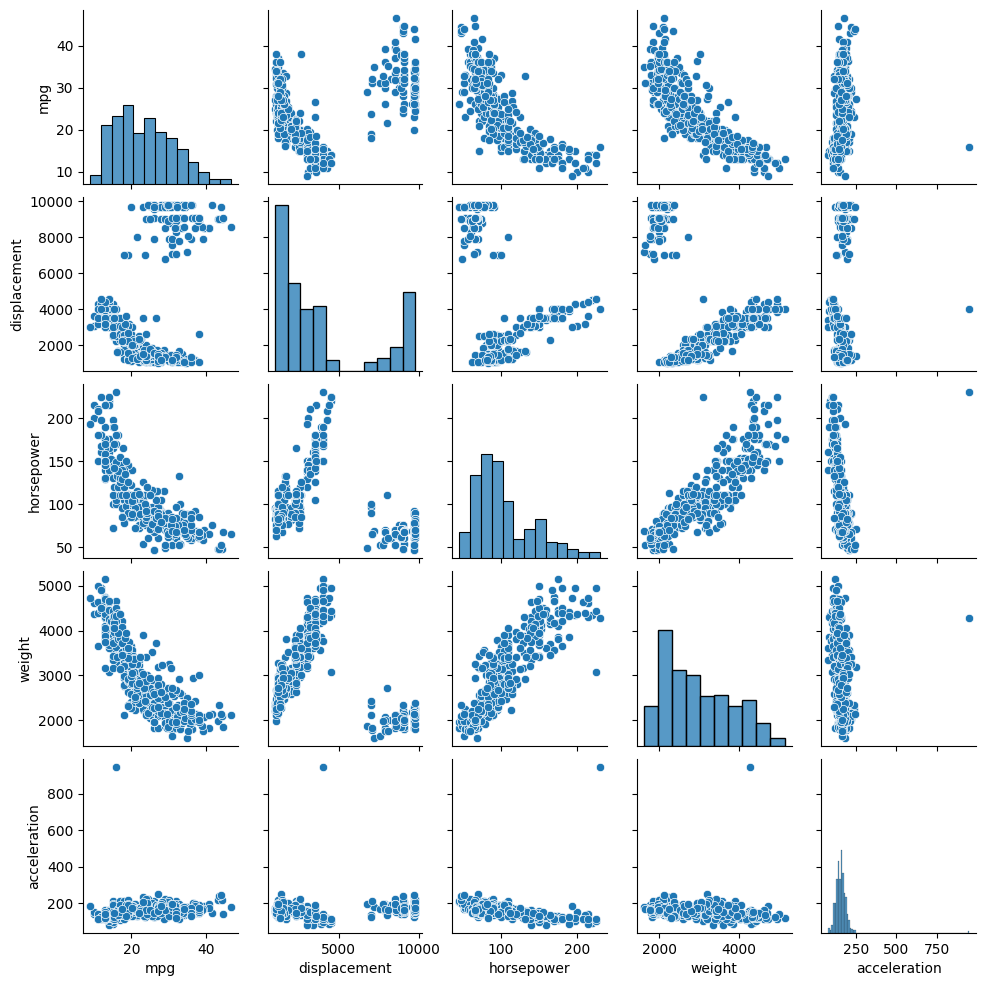

In [60]:
# @title
#-- representando variables numéricas con la librería seaborn --
import seaborn as sns

seleccion = df[["mpg", "displacement", "horsepower", "weight", "acceleration"]]
plt.figure()
sns.pairplot(seleccion, height=2, aspect=1)
plt.show()

# Medidas estadísticas

In [61]:
#-- medidas estadísticas de los atributos numéricos --
df.describe()

,mpg,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,406.000000,400.000000,406.000000,406.000000,406.000000,406.000000
mean,23.514573,3903.965517,105.082500,2979.413793,157.302956,75.921182,1.568966
std,7.815984,3035.047751,38.768779,847.004328,48.293591,3.748737,0.797479
min,9.000000,1000.000000,46.000000,1613.000000,80.000000,70.000000,1.000000
25%,17.500000,1460.000000,75.750000,2226.500000,137.250000,73.000000,1.000000
50%,23.000000,2620.000000,95.000000,2822.500000,155.000000,76.000000,1.000000
75%,29.000000,4505.000000,130.000000,3618.250000,172.000000,79.000000,2.000000
max,46.600000,9800.000000,230.000000,5140.000000,950.000000,82.000000,3.000000


In [63]:
#-- medidas estadísticas de los atributos cualitativos --
df[["cylinders", "car_name"]].describe()

,cylinders,car_name
count,406,406
unique,5,312
top,cuatro,ford pinto
freq,207,6


## Calculando medidas de tendencia central

In [65]:
# Analizando un atributo específico
col = 'acceleration'
min_val = df[col].min()
max_val = df[col].max()
median = df[col].median()
mode = df[col].mode()[0] if not df[col].mode().empty else None
midrange = (max_val + min_val) / 2

print(f"Atributo: {col}\nMin: {min_val}\nMax: {max_val}\nMediana: {median}\nModa: {mode}\nRango_medio: {midrange}")

Atributo: acceleration
Min: 80
Max: 950
Mediana: 155.0
Moda: 145
Rango_medio: 515.0


In [66]:
def getCentralTendency(col):
    min_val = df[col].min()
    max_val = df[col].max()
    median = df[col].median()
    mode = df[col].mode()[0] if not df[col].mode().empty else None
    midrange = (max_val + min_val) / 2  # Ajustado para ser el punto medio real

    return pd.DataFrame({
        "Atributo": [col],
        "Min": [min_val],
        "Max": [max_val],
        "Mediana": [median],
        "Moda": [mode],
        "Rango_medio": [midrange]
    })

# Concatenamos los resultados en un solo DataFrame
stats_df = pd.concat([getCentralTendency(col) for col in df.columns[[0,2,3,4,5]]], ignore_index=True)

# Mostramos el resultado de forma ordenada
print(stats_df)

       Atributo     Min     Max  Mediana    Moda  Rango_medio
0           mpg     9.0    46.6     23.0    13.0         27.8
1  displacement  1000.0  9800.0   2620.0  9700.0       5400.0
2    horsepower    46.0   230.0     95.0   150.0        138.0
3        weight  1613.0  5140.0   2822.5  1985.0       3376.5
4  acceleration    80.0   950.0    155.0   145.0        515.0


## Calculando medidas de dispersión

In [68]:
def getDispersion(col):
    range_val = df[col].max() - df[col].min()
    quantiles = df[col].quantile([0.25, 0.5, 0.75])
    IQR = quantiles[0.75] - quantiles[0.25]
    var = df[col].var()
    std = df[col].std()

    print(f"{col.ljust(15)} {str(range_val).ljust(10)} {str(quantiles[0.25]).ljust(10)} {str(quantiles[0.5]).ljust(10)} "
          f"{str(quantiles[0.75]).ljust(10)} {str(IQR).ljust(10)} {str(var).ljust(20)} {str(std).ljust(10)}")

# Imprimir encabezados
print(f"{'Atributo'.ljust(15)} {'Rango'.ljust(10)} {'Q1'.ljust(10)} {'Q2'.ljust(10)} {'Q3'.ljust(10)} {'IQR'.ljust(10)} {'Varianza'.ljust(20)} {'Desv.Std'.ljust(10)}")
print("-" * 110)  # Línea separadora

# Recorrer las columnas e imprimir valores en formato tabular
for col in df.columns[2:6]:
    getDispersion(col)


Atributo        Rango      Q1         Q2         Q3         IQR        Varianza             Desv.Std  
--------------------------------------------------------------------------------------------------------------
displacement    8800       1460.0     2620.0     4505.0     3045.0     9211514.853128998    3035.047751375421
horsepower      184.0      75.75      95.0       130.0      54.25      1503.0182393483724   38.76877918310522
weight          3527       2226.5     2822.5     3618.25    1391.75    717416.3320561941    847.0043282393509
acceleration    870        137.25     155.0      172.0      34.75      2332.270954205434    48.29359123326235


# Matriz de correlación

In [69]:
# Calculamos la matriz de correlación utilizando algunos atributos numéricos
corr_matrix = df[['mpg','displacement','horsepower','weight','acceleration']].corr()
print(corr_matrix)

                   mpg  displacement  horsepower    weight  acceleration
mpg           1.000000      0.402229   -0.778427 -0.831741      0.196969
displacement  0.402229      1.000000   -0.290504 -0.390601      0.107432
horsepower   -0.778427     -0.290504    1.000000  0.866586     -0.260496
weight       -0.831741     -0.390601    0.866586  1.000000     -0.182637
acceleration  0.196969      0.107432   -0.260496 -0.182637      1.000000


El valor del coeficiente de correlación entre los atributos "mpg" y "horsepower" es -0.778427.

En el siguiente diagrama de dispersión puede verse que los autos con mayor rendimiento en millas por galón son los que tienen menor potencia de motor y tienen valor de origen=3 es decir que fueron fabricados en Japón.

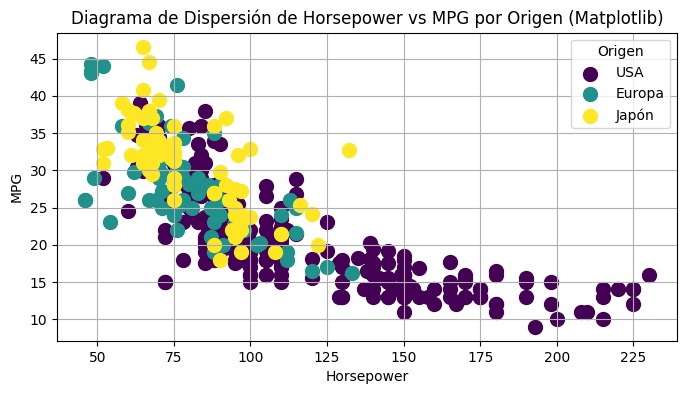

In [71]:
# @title
plt.figure(figsize=(8, 4))

hue_labels = {1: 'USA', 2: 'Europa', 3: 'Japón'}

# Get unique origins and sort them to ensure consistent color mapping
origins = sorted(df['origin'].unique())

# Create a colormap for distinct colors
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(origins))) # Get evenly spaced colors from the colormap

for i, origin_val in enumerate(origins):
    subset = df[df['origin'] == origin_val]
    plt.scatter(
        subset['horsepower'],
        subset['mpg'],
        label=hue_labels.get(origin_val, f'Origen {origin_val}'), # Use the defined label or a fallback
        color=colors[i],
        s=100 # Match the size from the previous seaborn plot
    )

plt.title('Diagrama de Dispersión de Horsepower vs MPG por Origen (Matplotlib)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend(title='Origen')
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

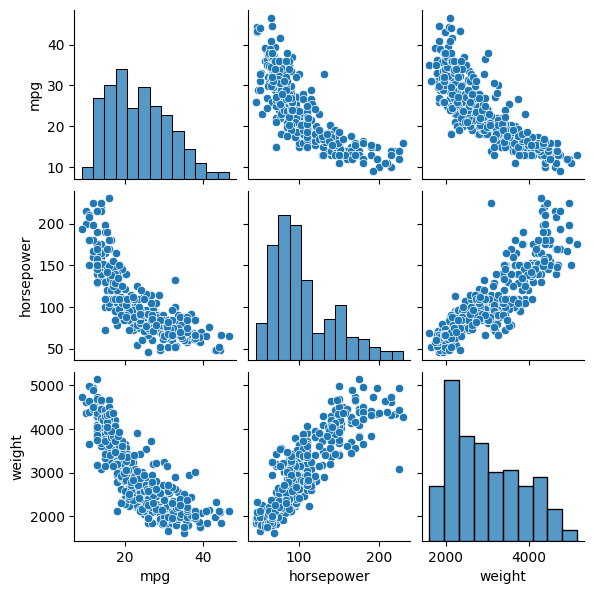

In [75]:
seleccion = df[["mpg", "horsepower", "weight"]]
plt.figure()
sns.pairplot(seleccion, height=2, aspect=1)
plt.show()